LIBRARY
numpy untuk pengolahan array dan operasi numerik pada citra digital.

cv2 untuk membantu proses pengolahan citra, terutama konversi warna RGB ke grayscale.

matplotlib.pyplot untuk menampilkan hasil visualisasi citra seperti citra asli, grayscale, hasil masking, edge detection, dan highlight objek.

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

MEMBACA DAN MENAMPILKAN CITRA

Digunakan untuk membaca citra backup.jpg menggunakan matplotlib, kemudian menampilkan citra asli sebagai input awal proses pengolahan citra.

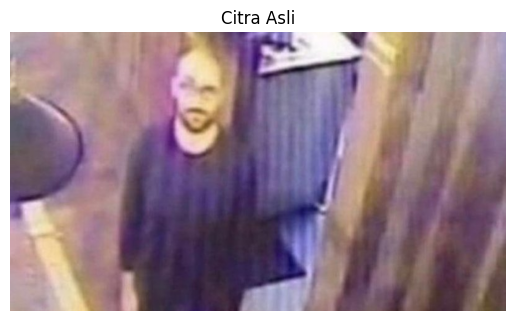

In [29]:
backup = plt.imread('backup.jpg')

plt.imshow(backup)
plt.title('Citra Asli')
plt.axis('off')
plt.show()

CITRA GRAYSCALE

Digunakan untuk mengubah citra berwarna RGB menjadi citra grayscale menggunakan OpenCV. Dilakukan untuk menyederhanakan informasi citra sehingga pengolahan seperti thresholding, masking, dan deteksi objek menjadi lebih mudah karena hanya menggunakan intensitas keabuan. Setelah dikonversi, citra grayscale ditampilkan menggunakan colormap abu-abu.

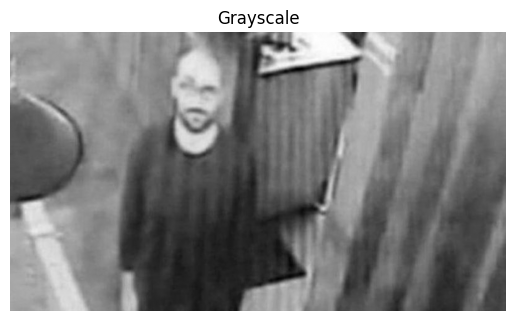

In [30]:
backup_gray = cv2.cvtColor(backup, cv2.COLOR_RGB2GRAY)

plt.imshow(backup_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.show()

KERNEL 

Digunakan untuk membuat kernel smoothing dan sharpening yang akan dipakai pada proses konvolusi citra. Kernel smoothing berfungsi untuk menghaluskan citra dan mengurangi noise dengan cara meratakan nilai piksel di sekitarnya, sedangkan kernel sharpening digunakan untuk mempertajam detail dan tepi objek pada citra sehingga bentuk objek terlihat lebih jelas.

In [31]:
kernelSmoothing = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

kernelSharpening = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

FUNGSI KONVOLUSI

Fungsi convolution() digunakan untuk melakukan proses konvolusi secara manual antara citra dan kernel filter. Proses ini dilakukan dengan mengalikan setiap area piksel citra dengan nilai kernel, kemudian menjumlahkannya untuk menghasilkan nilai piksel baru. Padding ditambahkan di tepi citra agar proses konvolusi tetap dapat dilakukan pada seluruh area gambar. 

In [32]:
def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    height, width = img.shape
    canvas = np.zeros_like(img, dtype=np.float32)

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)

    return canvas

SMOOTHING DAN SHARPENING

Digunakan untuk menerapkan proses smoothing dan sharpening pada citra grayscale menggunakan fungsi konvolusi yang telah dibuat sebelumnya. 

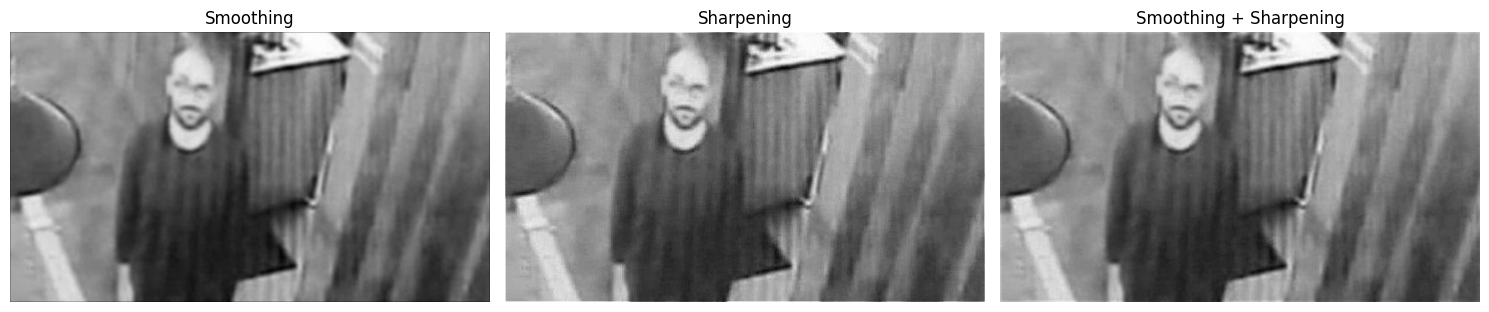

In [33]:
hasil_smoothing = convolution(backup_gray, kernelSmoothing)
hasil_smoothing = np.clip(hasil_smoothing, 0, 255).astype(np.uint8)

hasil_sharpening = convolution(backup_gray, kernelSharpening)
hasil_sharpening = np.clip(hasil_sharpening, 0, 255).astype(np.uint8)

hasil_smooth_sharp = convolution(hasil_smoothing, kernelSharpening)
hasil_smooth_sharp = np.clip(hasil_smooth_sharp, 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(hasil_smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hasil_sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_smooth_sharp, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')

plt.tight_layout()
plt.show()

Hasil smoothing digunakan untuk mengurangi noise dan menghaluskan citra, sedangkan hasil sharpening digunakan untuk memperjelas detail objek dan tepi citra. Selain itu, dilakukan kombinasi smoothing dan sharpening agar citra tetap halus namun detail objek tetap terlihat jelas. 

Mean filter menghasilkan citra yang lebih halus karena menggunakan rata-rata nilai piksel di sekitarnya, tetapi detail dan tepi objek biasanya menjadi blur. Median filter lebih efektif untuk mengurangi noise, terutama noise salt and pepper, karena menggunakan nilai tengah piksel sehingga hasil citra lebih bersih dan tepi objek tetap cukup terjaga. Sementara itu, modus filter menggunakan nilai piksel yang paling sering muncul di area sekitar sehingga dapat mempertahankan intensitas dominan pada citra, namun beberapa detail halus bisa berkurang dan area citra terlihat lebih seragam.

EDGE DETECTION

Fungsi edge_detection() digunakan untuk menghitung kekuatan tepi objek pada citra berdasarkan gradien horizontal (gx) dan vertikal (gy). 

In [34]:
def edge_detection(gx, gy):

    total = np.sqrt(
        (gx ** 2) + (gy ** 2)
    )

    total = (
        total / np.max(total)
    ) * 255

    total = total.astype(np.uint8)

    return total

KERNEL EDGE DETECTION

Digunakan untuk membuat kernel deteksi tepi metode Sobel, Prewitt, dan Roberts pada arah horizontal (X) dan vertikal (Y). Kernel digunakan untuk menghitung perubahan intensitas piksel pada citra sehingga tepi objek dapat terdeteksi. 

In [35]:
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

EDGE DETECTION

Digunakan untuk menerapkan metode deteksi tepi Prewitt, Sobel, dan Roberts pada citra grayscale menggunakan proses konvolusi. Kombinasi kernel dilakukan dengan menjumlahkan hasil gradien horizontal dan vertikal dari setiap metode sehingga tepi objek pada citra dapat terlihat lebih jelas. 

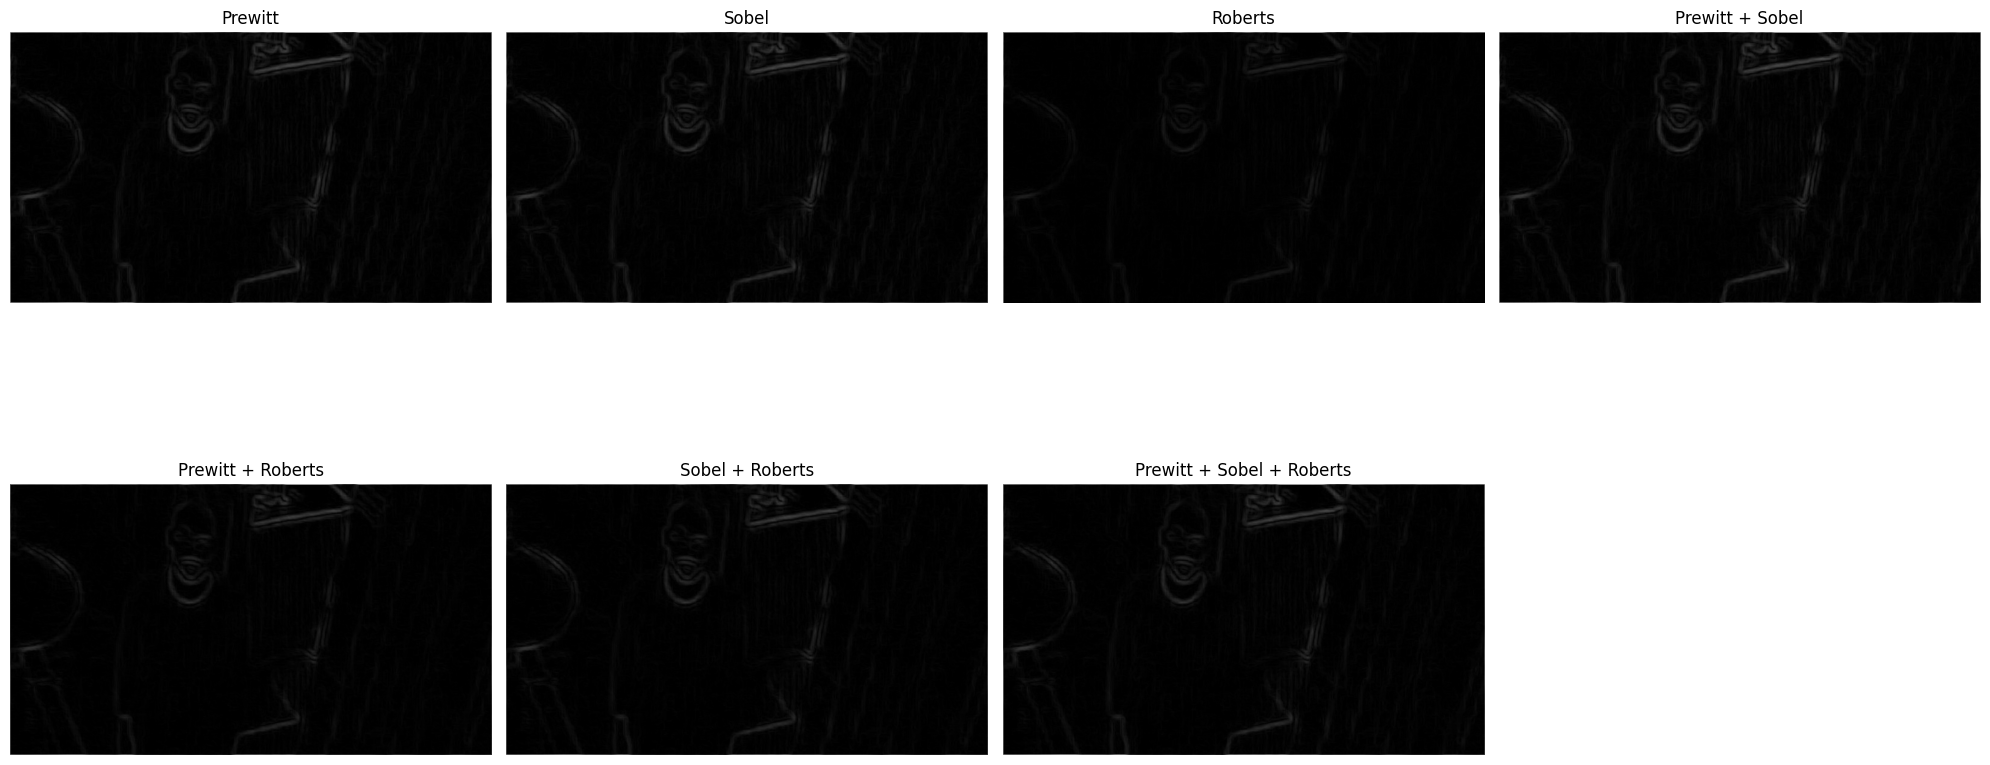

In [36]:
prewitt = edge_detection(convolution(backup_gray, prewittX), convolution(backup_gray, prewittY))
sobel = edge_detection(convolution(backup_gray, sobelX), convolution(backup_gray, sobelY))
roberts = edge_detection(convolution(backup_gray, robertsX), convolution(backup_gray, robertsY))

prewitt_sobel = edge_detection(convolution(backup_gray, prewittX) + convolution(backup_gray, sobelX),
                               convolution(backup_gray, prewittY) + convolution(backup_gray, sobelY))
prewitt_roberts = edge_detection(convolution(backup_gray, prewittX) + convolution(backup_gray, robertsX),
                                 convolution(backup_gray, prewittY) + convolution(backup_gray, robertsY))
sobel_roberts = edge_detection(convolution(backup_gray, sobelX) + convolution(backup_gray, robertsX),
                               convolution(backup_gray, sobelY) + convolution(backup_gray, robertsY))
prewitt_sobel_roberts = edge_detection(convolution(backup_gray, prewittX) + convolution(backup_gray, sobelX) + convolution(backup_gray, robertsX),
                                       convolution(backup_gray, prewittY) + convolution(backup_gray, sobelY) + convolution(backup_gray, robertsY))

plt.figure(figsize=(20, 10))

plt.subplot(2, 4, 1)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(prewitt_sobel_roberts, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()

ANALISIS KEGUNAAN OPERATOR DAN KOMBINASINYA

Operator Sobel digunakan untuk mendeteksi tepi dengan hasil yang lebih halus dan sensitif terhadap perubahan intensitas piksel sehingga cocok untuk menampilkan detail objek dengan lebih jelas. Operator Prewitt memiliki fungsi serupa namun dengan perhitungan yang lebih sederhana sehingga mampu mendeteksi arah tepi horizontal dan vertikal dengan cukup baik. Sementara itu, operator Roberts menggunakan kernel berukuran kecil sehingga lebih cepat dalam mendeteksi perubahan intensitas, tetapi lebih sensitif terhadap noise. Kombinasi dari operator-operator tersebut digunakan untuk menggabungkan keunggulan masing-masing metode agar hasil deteksi tepi menjadi lebih detail, lebih jelas, dan mampu menangkap lebih banyak informasi tepi pada citra dibandingkan menggunakan satu operator saja.

THRESHOLDING

Fungsi threshold() digunakan untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai tertentu. Piksel yang memiliki intensitas lebih besar dari nilai threshold akan diubah menjadi putih (255), sedangkan piksel lainnya menjadi hitam (0). Proses ini bertujuan untuk memisahkan objek dari background sehingga area penting pada citra menjadi lebih mudah dianalisis pada proses selanjutnya.

In [37]:
def threshold(img, nilai):
    hasil = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] > nilai:
                hasil[i, j] = 255
            else:
                hasil[i, j] = 0
    return hasil

THRESHOLDING

Menerapkan beberapa nilai threshold pada hasil deteksi tepi Sobel untuk membandingkan pengaruh nilai terhadap hasil citra biner. Setiap nilai threshold akan menghasilkan tingkat pemisahan objek dan background yang berbeda, di mana threshold rendah cenderung menampilkan lebih banyak detail dan noise, sedangkan threshold tinggi hanya menampilkan tepi objek yang lebih kuat. 

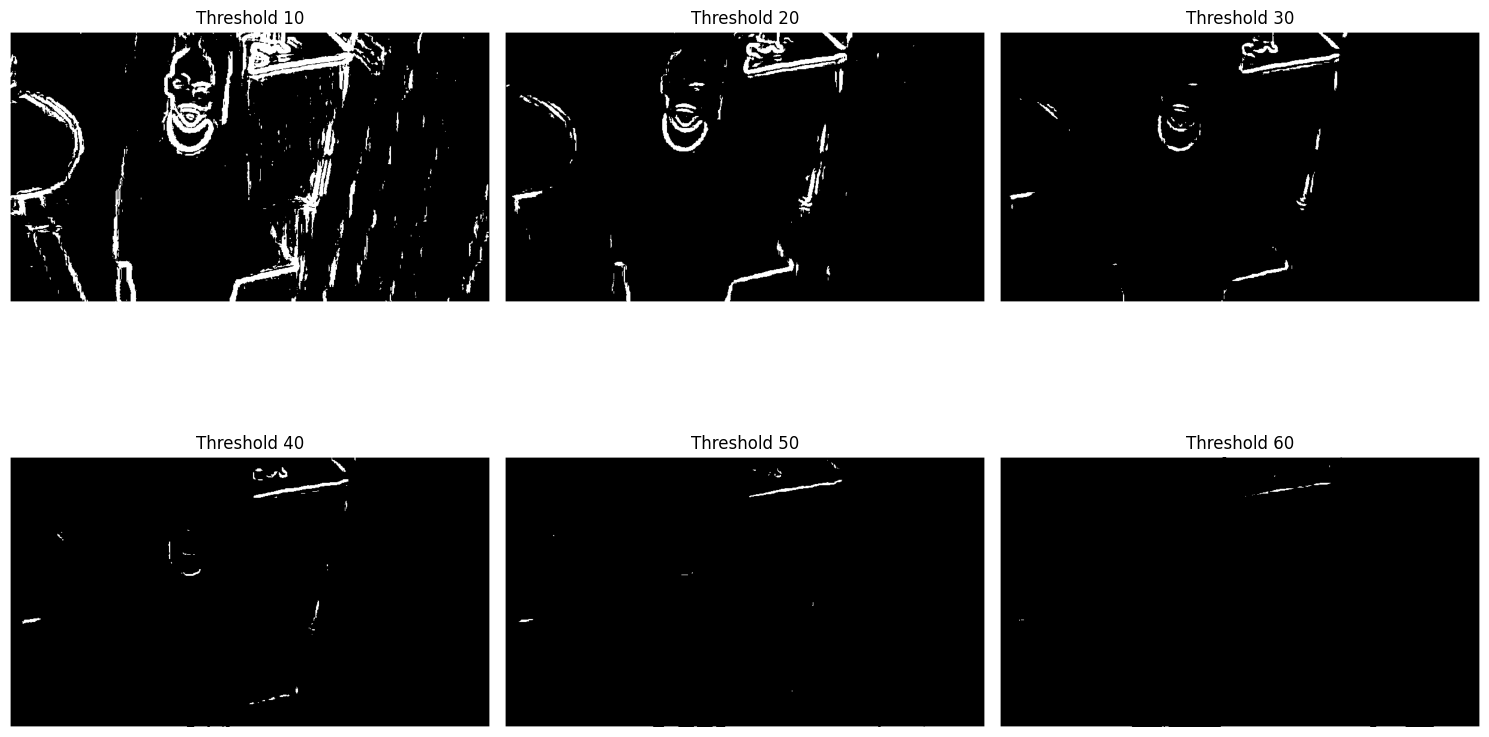

In [38]:
thresholds = [10, 20, 30, 40, 50, 60]

plt.figure(figsize=(15, 10))

for idx, nilai in enumerate(thresholds):
    hasil = threshold(sobel, nilai)
    plt.subplot(2, 3, idx + 1)
    plt.imshow(hasil, cmap='gray')
    plt.title(f'Threshold {nilai}')
    plt.axis('off')

plt.tight_layout()
plt.show()

PENGARUH PENGGUNAAN THRESHOLD

Penggunaan threshold mempengaruhi jumlah detail dan tepi objek yang ditampilkan pada citra biner hasil deteksi tepi. Threshold rendah akan menghasilkan lebih banyak piksel putih sehingga detail objek dan noise lebih banyak terlihat, sedangkan threshold tinggi hanya mempertahankan tepi dengan intensitas kuat sehingga hasil menjadi lebih bersih tetapi beberapa detail objek dapat hilang. Nilai threshold sekitar 40 paling baik karena mampu menampilkan bentuk objek dengan cukup jelas tanpa terlalu banyak noise, sehingga tepi objek masih terlihat detail namun background yang tidak diperlukan dapat dikurangi.

HIGHLIGHT 

Melakukan proses deteksi area tubuh dan kepala manusia pada citra CCTV menggunakan teknik masking berdasarkan intensitas grayscale dan batas area tertentu. Setelah area tubuh dan kepala diperoleh, dilakukan proses dilasi dan filling untuk memperjelas bentuk objek sehingga area manusia lebih terlihat. Selanjutnya dibuat mask dan edge untuk menampilkan bentuk objek yang terdeteksi, kemudian dilakukan proses highlight dengan memberikan overlay dan bounding box berwarna kuning pada area tubuh dan kepala manusia. Hasil akhir menampilkan area manusia yang lebih menonjol sehingga objek pada citra CCTV lebih terlihat.

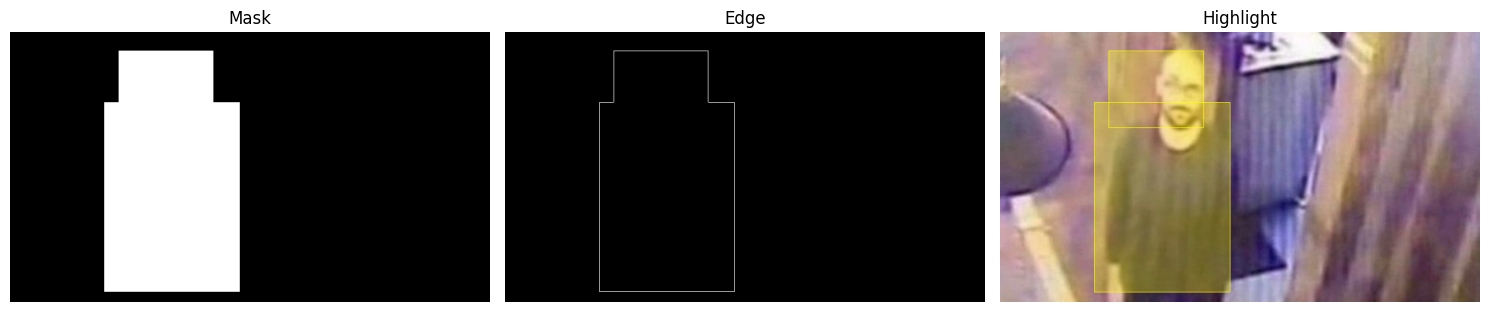

In [39]:
gray = backup_gray.copy()

mask_badan = np.zeros_like(gray)
mask_kepala = np.zeros_like(gray)

for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):

        if (
            gray[i, j] < 125 and
            j > 160 and
            j < 380 and
            i > 120 and
            i < 430
        ):

            mask_badan[i, j] = 255

        if (
            gray[i, j] > 120 and
            gray[i, j] < 210 and
            j > 180 and
            j < 340 and
            i > 30 and
            i < 160
        ):

            mask_kepala[i, j] = 255

kernel = 9
pad = kernel // 2

dilate_badan = np.zeros_like(mask_badan)

for i in range(pad, mask_badan.shape[0] - pad):
    for j in range(pad, mask_badan.shape[1] - pad):

        area = mask_badan[
            i-pad:i+pad+1,
            j-pad:j+pad+1
        ]

        if np.max(area) == 255:
            dilate_badan[i, j] = 255

fill_badan = dilate_badan.copy()

for i in range(fill_badan.shape[0]):

    putih = []

    for j in range(fill_badan.shape[1]):

        if fill_badan[i, j] == 255:
            putih.append(j)

    if len(putih) > 1:

        kiri = min(putih)
        kanan = max(putih)

        for j in range(kiri, kanan):
            fill_badan[i, j] = 255

y_badan = []
x_badan = []

for i in range(fill_badan.shape[0]):
    for j in range(fill_badan.shape[1]):

        if fill_badan[i, j] == 255:

            y_badan.append(i)
            x_badan.append(j)

y1_badan = min(y_badan)
y2_badan = max(y_badan)

x1_badan = min(x_badan)
x2_badan = max(x_badan)

y_kepala = []
x_kepala = []

for i in range(mask_kepala.shape[0]):
    for j in range(mask_kepala.shape[1]):

        if mask_kepala[i, j] == 255:

            y_kepala.append(i)
            x_kepala.append(j)

y1_kepala = min(y_kepala)
y2_kepala = max(y_kepala)

x1_kepala = min(x_kepala)
x2_kepala = max(x_kepala)

mask_final = np.zeros_like(gray)

for i in range(y1_badan, y2_badan):
    for j in range(x1_badan, x2_badan):

        mask_final[i, j] = 255

for i in range(y1_kepala, y2_kepala):
    for j in range(x1_kepala, x2_kepala):

        mask_final[i, j] = 255

edge = np.zeros_like(mask_final)

for i in range(1, mask_final.shape[0]-1):
    for j in range(1, mask_final.shape[1]-1):

        if mask_final[i, j] == 255:

            if (
                mask_final[i-1, j] == 0 or
                mask_final[i+1, j] == 0 or
                mask_final[i, j-1] == 0 or
                mask_final[i, j+1] == 0
            ):

                edge[i, j] = 255

hasil = backup.copy()

overlay = hasil.copy()

for i in range(y1_badan, y2_badan):
    for j in range(x1_badan, x2_badan):

        overlay[i, j] = [255, 255, 0]

for i in range(y1_kepala, y2_kepala):
    for j in range(x1_kepala, x2_kepala):

        overlay[i, j] = [255, 255, 0]

hasil = (
    0.7 * hasil +
    0.3 * overlay
).astype(np.uint8)

for j in range(x1_badan, x2_badan):

    hasil[y1_badan, j] = [255, 255, 0]
    hasil[y2_badan, j] = [255, 255, 0]

for i in range(y1_badan, y2_badan):

    hasil[i, x1_badan] = [255, 255, 0]
    hasil[i, x2_badan] = [255, 255, 0]

for j in range(x1_kepala, x2_kepala):

    hasil[y1_kepala, j] = [255, 255, 0]
    hasil[y2_kepala, j] = [255, 255, 0]

for i in range(y1_kepala, y2_kepala):

    hasil[i, x1_kepala] = [255, 255, 0]
    hasil[i, x2_kepala] = [255, 255, 0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(mask_final, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edge, cmap='gray')
plt.title('Edge')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(hasil)
plt.title('Highlight')
plt.axis('off')

plt.tight_layout()
plt.show()

ANALISIS HASIL DETEKSI OBJEK MANUSIA

Hasil output menunjukkan bahwa proses masking berhasil memisahkan area tubuh dan kepala manusia dari background citra CCTV. Pada bagian Mask, area tubuh dan kepala ditampilkan sebagai objek putih di atas background hitam sehingga bentuk objek manusia menjadi lebih jelas. Pada bagian Edge, garis tepi objek berhasil dideteksi dengan baik sehingga bentuk outline tubuh dan kepala dapat terlihat. Pada bagian Highlight, sistem berhasil memberikan overlay dan bounding box berwarna kuning pada area manusia sehingga objek utama pada citra menjadi lebih menonjol dan mudah diamati. 

DETEKSI TEPI 

Melakukan proses deteksi tepi dan penghapusan background pada citra david.jpg. Pertama, citra diubah menjadi grayscale untuk mempermudah proses deteksi tepi menggunakan operator Sobel sehingga bentuk objek dapat terlihat lebih jelas. Selanjutnya dibuat fungsi median filter untuk mengurangi noise dan merapikan hasil citra. Proses masking memanfaatkan perbandingan kanal RGB untuk mendeteksi background berwarna toska, di mana area dengan dominasi warna hijau dan biru dianggap sebagai background. Setelah mask diperoleh dan dirapikan menggunakan median filter, area background diubah menjadi warna putih jadi hanya objek utama yang dipertahankan.

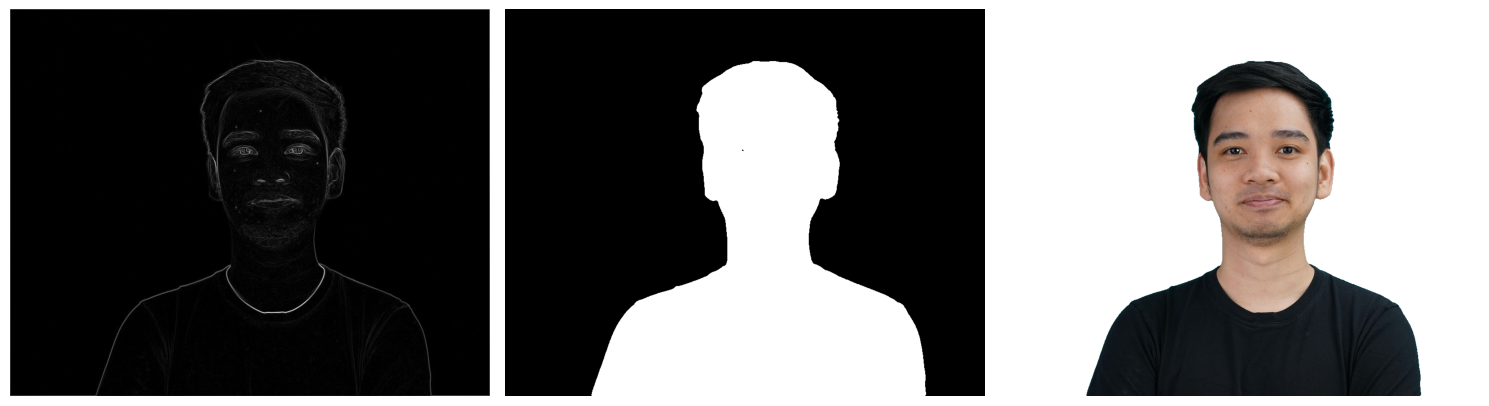

In [40]:
david = plt.imread('david.jpg')

david_gray = cv2.cvtColor(david, cv2.COLOR_RGB2GRAY)

david_sobel = edge_detection(convolution(david_gray, sobelX), convolution(david_gray, sobelY))

def median_filter(img, ukuran):

    pad = ukuran // 2

    padded = np.pad(img, pad, mode='constant')

    hasil = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            area = padded[
                i:i+ukuran,
                j:j+ukuran
            ]

            hasil[i, j] = np.median(area)

    return hasil

david_median = median_filter(david_gray, 5)

mask_david = np.zeros(david.shape[:2], dtype=np.uint8)

for i in range(david.shape[0]):
    for j in range(david.shape[1]):

        r = int(david[i, j, 0])
        g = int(david[i, j, 1])
        b = int(david[i, j, 2])

        if (
            g > r and
            b > r and
            g > 80 and
            b > 80
        ):

            mask_david[i, j] = 0

        else:

            mask_david[i, j] = 255

mask_david = median_filter(mask_david, 5)

david_hasil = david.copy()

for i in range(david.shape[0]):
    for j in range(david.shape[1]):

        if mask_david[i, j] == 0:

            david_hasil[i, j] = [255, 255, 255]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(david_sobel, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask_david, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(david_hasil)
plt.axis('off')

plt.tight_layout()
plt.show()

PENGHILANGAN BACKGROUND

Proses dimulai dengan membaca citra david.jpg kemudian mengubahnya menjadi citra grayscale untuk mempermudah proses pengolahan dan deteksi tepi menggunakan operator Sobel. Hasil deteksi tepi digunakan untuk memperjelas bentuk objek pada citra. Selanjutnya dilakukan proses pemisahan background menggunakan perbandingan kanal RGB, di mana background berwarna toska dideteksi berdasarkan dominasi nilai kanal hijau dan biru dibandingkan kanal merah. Piksel yang memenuhi kondisi tersebut dianggap sebagai background dan diberi nilai 0 pada mask, sedangkan area foreground atau objek utama dipertahankan dengan nilai 255. Setelah itu, median filter digunakan untuk mengurangi noise dan merapikan hasil mask agar area objek menjadi lebih bersih. Pada tahap akhir, area background pada citra asli diubah menjadi warna putih sehingga hanya objek utama yang tetap terlihat, menghasilkan efek background removal.